### 1. Problem Definition

We aim to predict the wildfire events likelihood that the fire comes within 5 km of an evacuation zone at different future time horizon: [prob_12h prob_24h prob_48h prob_72h]


Target Y:  
* time_to_hit_hours = time until the wildfire reaches the zone
* event(wildfire) = 1 if it reached, 0 if censored

Feature X: test and train data columns


Our goal is to imporve the metrics:  
* HybridScore = 0.3 × C-inde x+ 0.7 × (1 − Weighted Brier Score)

### Load Data

In [198]:
import pandas as pd
import numpy as np

# Load Data
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

# check data stucture
print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()


Train shape: (221, 37)
Test shape: (95, 35)


,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
0,10892457,3,4.265188,0,79.696304,2.875935,0.036086,0.674281,4.390693,1.354787,...,0.886373,-0.054649,0.054649,-1.937219,-0.106026,19,4,5,18.892512,0
1,11757157,2,1.169918,0,8.946749,0.000000,0.000000,0.000000,2.297246,0.000000,...,0.000000,-0.568898,0.568898,-0.000000,-0.000000,4,4,6,22.048108,1
2,11945086,4,4.777526,0,106.482638,0.000000,0.000000,0.000000,4.677329,0.000000,...,0.000000,0.882385,0.882385,0.000000,0.000000,22,4,8,0.888895,1
3,12044083,1,0.000000,1,67.631125,0.000000,0.000000,0.000000,4.228746,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,20,5,8,60.953021,0
4,12052347,2,4.975273,0,35.632874,0.000000,0.000000,0.000000,3.600946,0.000000,...,0.000000,0.934634,0.934634,-0.000000,0.000000,21,5,7,44.990274,0


### Check Missing Values & Define Features

In [199]:
# Check missing vals
missing_train = train.isnull().sum().sum()
missing_test = test.isnull().sum().sum()

print("Total missing values in train:", missing_train)
print("Total missing values in test:", missing_test)

Total missing values in train: 0
Total missing values in test: 0


In [200]:
# targets
Y_time = train["time_to_hit_hours"]
Y_event = train["event"]

# Feature columns (exclude ID and target variables)
FEATURE_COLS = [
    col for col in train.columns
    if col not in ["event_id", "time_to_hit_hours", "event"]
]

X = train[FEATURE_COLS]
X_test = test[FEATURE_COLS]

print("Total number of features:", len(FEATURE_COLS))

Total number of features: 34


In [201]:
train.shape
train.head()

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
0,10892457,3,4.265188,0,79.696304,2.875935,0.036086,0.674281,4.390693,1.354787,...,0.886373,-0.054649,0.054649,-1.937219,-0.106026,19,4,5,18.892512,0
1,11757157,2,1.169918,0,8.946749,0.000000,0.000000,0.000000,2.297246,0.000000,...,0.000000,-0.568898,0.568898,-0.000000,-0.000000,4,4,6,22.048108,1
2,11945086,4,4.777526,0,106.482638,0.000000,0.000000,0.000000,4.677329,0.000000,...,0.000000,0.882385,0.882385,0.000000,0.000000,22,4,8,0.888895,1
3,12044083,1,0.000000,1,67.631125,0.000000,0.000000,0.000000,4.228746,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,20,5,8,60.953021,0
4,12052347,2,4.975273,0,35.632874,0.000000,0.000000,0.000000,3.600946,0.000000,...,0.000000,0.934634,0.934634,-0.000000,0.000000,21,5,7,44.990274,0


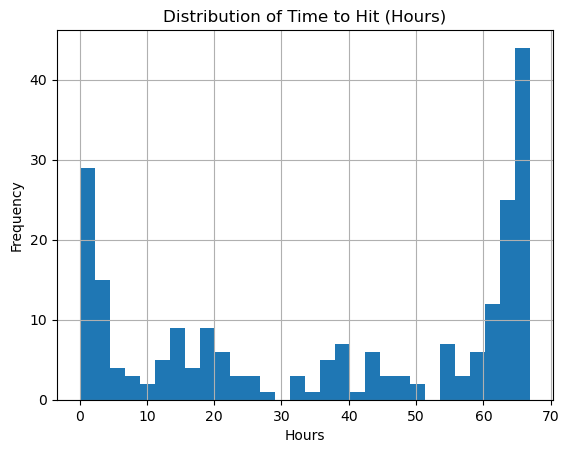

In [202]:
# Visualize 
import matplotlib.pyplot as plt

train["time_to_hit_hours"].hist(bins=30)
plt.title("Distribution of Time to Hit (Hours)")
plt.xlabel("Hours")
plt.ylabel("Frequency")
plt.show()


### 2. DATA UNDERSTANDING AND AUDIT



In [203]:
# some basic stats on the datasets
# Event distribution
print(f"\nEvent distribution:")
event_counts = train["event"].value_counts().sort_index()
print(f"  Censored (0): {event_counts.get(0, 0)} ({event_counts.get(0, 0)/len(train)*100:.1f}%)")
print(f"  Hit (1): {event_counts.get(1, 0)} ({event_counts.get(1, 0)/len(train)*100:.1f}%)")

# Time to hit stats (for events that hit)
hits = train[train["event"] == 1]
print(f"\nTime-to-hit distribution (hits only, n={len(hits)}):")
print(f"  Mean: {hits['time_to_hit_hours'].mean():.1f}h")
print(f"  Median: {hits['time_to_hit_hours'].median():.1f}h")
print(f"  Min: {hits['time_to_hit_hours'].min():.1f}h")
print(f"  Max: {hits['time_to_hit_hours'].max():.1f}h")
print(f"  25th: {hits['time_to_hit_hours'].quantile(0.25):.1f}h")
print(f"  75th: {hits['time_to_hit_hours'].quantile(0.75):.1f}h")

# Horizon feasibility
print(f"\nHits by horizon (feasibility check):")
for h in [12, 24, 48, 72]:
    n_hits = ((train["time_to_hit_hours"] <= h) & (train["event"] == 1)).sum()
    print(f"  ≤{h:2d}h: {n_hits:3d} hits ({n_hits/len(train)*100:.1f}% of dataset)")



Event distribution:
  Censored (0): 152 (68.8%)
  Hit (1): 69 (31.2%)

Time-to-hit distribution (hits only, n=69):
  Mean: 10.0h
  Median: 3.5h
  Min: 0.0h
  Max: 66.9h
  25th: 0.9h
  75th: 14.3h

Hits by horizon (feasibility check):
  ≤12h:  49 hits (22.2% of dataset)
  ≤24h:  63 hits (28.5% of dataset)
  ≤48h:  66 hits (29.9% of dataset)
  ≤72h:  69 hits (31.2% of dataset)


In [204]:
# Missing values audit
FEATURE_COLS = [col for col in train.columns 
                if col not in ["event_id", "time_to_hit_hours", "event"]]

missing_train = train[FEATURE_COLS].isnull().sum()
missing_test = test[FEATURE_COLS].isnull().sum()

if missing_train.sum() == 0:
    print("\nNo missing values in training features.")
else:
    print("\nMissing values in training features:")
    print(missing_train[missing_train > 0].sort_values(ascending=False))

if missing_test.sum() == 0:
    print("\nNo missing values in test features.")
else:
    print("\nMissing values in test features:")
    print(missing_test[missing_test > 0].sort_values(ascending=False))
    
# check for duplicates
n_dup = train.duplicated(subset=FEATURE_COLS).sum()
print(f"\nNumber of duplicate rows in training data: {n_dup}")


No missing values in training features.

No missing values in test features.

Number of duplicate rows in training data: 0


In [205]:
# data leakage check, features that are highly correlated with the target
# Correlation with target time (suspicious if too high)
print("\nTop 10 features correlated with time_to_hit:")
correlations = train[FEATURE_COLS].corrwith(train["time_to_hit_hours"]).abs()
top_corr = correlations.sort_values(ascending=False).head(10)
for col, corr in top_corr.items():
    flag = "⚠️ " if corr > 0.7 else "  "
    print(f"{flag} {col:40s}: {corr:.3f}")

# Perfect separation check
print("\nChecking for perfect event separation:")
n_perfect = 0
for col in FEATURE_COLS:
    hit_min = train[train["event"] == 1][col].min()
    cens_max = train[train["event"] == 0][col].max()
    if hit_min > cens_max:
        print(f"{col}: Hits always > Censored")
        n_perfect += 1
        
if n_perfect == 0:
    print("No perfect separation found")


Top 10 features correlated with time_to_hit:
   low_temporal_resolution_0_5h            : 0.442
   dt_first_last_0_5h                      : 0.435
   num_perimeters_0_5h                     : 0.392
   spread_bearing_cos                      : 0.370
   alignment_abs                           : 0.367
   spread_bearing_deg                      : 0.336
   dist_min_ci_0_5h                        : 0.325
   log1p_growth                            : 0.317
   dist_fit_r2_0_5h                        : 0.284
   log_area_ratio_0_5h                     : 0.228

Checking for perfect event separation:
No perfect separation found


In [206]:
# outliers - flag extreme outliers (5 IQR rule)
outlier_features = []
for col in FEATURE_COLS:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 5 * IQR
    upper = Q3 + 5 * IQR
    
    n_outliers = ((train[col] < lower) | (train[col] > upper)).sum()
    pct_outliers = n_outliers / len(train) * 100
    
    if pct_outliers > 5:  # Only flag if >5% are outliers
        outlier_features.append((col, n_outliers, pct_outliers))

if outlier_features:
    print(f"\nFeatures with >5% extreme outliers:")
    for col, n, pct in sorted(outlier_features, key=lambda x: x[2], reverse=True)[:10]:
        print(f"   {col:40s}: {n:3d} ({pct:5.1f}%)")
else:
    print("\nNo features with >5% extreme outliers")



Features with >5% extreme outliers:
   alignment_cos                           :  61 ( 27.6%)
   dist_slope_ci_0_5h                      :  52 ( 23.5%)
   alignment_abs                           :  45 ( 20.4%)
   dist_accel_m_per_h2                     :  35 ( 15.8%)
   area_growth_abs_0_5h                    :  25 ( 11.3%)
   area_growth_rel_0_5h                    :  25 ( 11.3%)
   area_growth_rate_ha_per_h               :  25 ( 11.3%)
   log_area_ratio_0_5h                     :  25 ( 11.3%)
   relative_growth_0_5h                    :  25 ( 11.3%)
   radial_growth_m                         :  25 ( 11.3%)


### 3. DATA PREP:

In [207]:
# Create binary labels for different horizons:
HORIZONS = [12, 24, 48, 72]

for horizon in HORIZONS:
    # Binary label: fire hit within this time window
    # Only label as 1 if event occurred AND time <= horizon
    train[f"hit_by_{horizon}h"] = (
        (train["event"] == 1) & (train["time_to_hit_hours"] <= horizon)
    ).astype(int)
    
    n_hits = train[f"hit_by_{horizon}h"].sum()
    print(f"\nHorizon {horizon:2d}h: {n_hits:3d} positives ({n_hits/len(train)*100:.1f}%)")
    
    FEATURE_COLS = [col for col in train.columns
                    if col not in ["event_id", "time_to_hit_hours", "event"] +
                    [f"hit_by_{h}h" for h in HORIZONS]]
    
    
print(f"\n Final feature count: {len(FEATURE_COLS)}")



Horizon 12h:  49 positives (22.2%)

Horizon 24h:  63 positives (28.5%)

Horizon 48h:  66 positives (29.9%)

Horizon 72h:  69 positives (31.2%)

 Final feature count: 34


### 4. CV setup

In [208]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

# using stratified for inbalanced dataset

# CV config
n_splits = 5
n_repeats = 1 # increase to 3 after baseline works 
random_state = 42

# Stratify on event label to maintain hit/censor balance
stratify_col = train["event"]

# Initialize CV splitter
cv = StratifiedKFold(n_splits=n_splits, 
                     shuffle=True, 
                     random_state=random_state
                     )

print(f"\nStrategy: {n_splits}-Fold Stratified (on 'event')")
print(f"Repeats: {n_repeats} (for stability testing)")
print(f"\nFold distribution:")

# Show fold sizes and event distribution in each fold:
for fold, (train_idx, val_idx) in enumerate(cv.split(train, stratify_col)):
    train_events = train.iloc[train_idx]["event"].sum()
    val_events = train.iloc[val_idx]["event"].sum()
    
    print(f"  Fold {fold+1}: Train={len(train_idx)} ({train_events} hits), "
          f"Val={len(val_idx)} ({val_events} hits)")





Strategy: 5-Fold Stratified (on 'event')
Repeats: 1 (for stability testing)

Fold distribution:
  Fold 1: Train=176 (55 hits), Val=45 (14 hits)
  Fold 2: Train=177 (56 hits), Val=44 (13 hits)
  Fold 3: Train=177 (55 hits), Val=44 (14 hits)
  Fold 4: Train=177 (55 hits), Val=44 (14 hits)
  Fold 5: Train=177 (55 hits), Val=44 (14 hits)


### 5. Baseline modeling: Random Survival Forest
- aim to add Cox for Emsemble modelling

In [209]:
from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv

In [210]:
# Get survival data format for sksurv
y_train = Surv.from_dataframe("event", "time_to_hit_hours", train)

# Baseline RSF modelling
rsf = RandomSurvivalForest(
    n_estimators=100,
    min_samples_split=10,
    min_samples_leaf=6,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

# fit train data
X = train[FEATURE_COLS]
rsf.fit(X, y_train)

# Get survival function predc for test set
survival_funcs = rsf.predict_survival_function(test[FEATURE_COLS])

### Extract Horizon Probability 

In [211]:
def extract_horizon_probability(survival_funcs, horizons=[12, 24, 48, 72]):
    """
    Extract P(hit by horizon) from survival functions.
    Survival = P(survive past t) = P(NOT hit by t)
    So: P(hit by t) = 1 - S(t)
    """
    probs =[]
    for func in survival_funcs:
        fire_probs = {}
        max_time = func.domain[1]
        for h in horizons:
            if h <= max_time:
                # Within observed range, can directly get survival prob
                surv_at_h = func(h)
                prob_hit = 1 - surv_at_h
            else:
                # This exceeds observed time
                # Use survival probability at max time
                surv_at_max = func(max_time)
                prob_hit = 1 - surv_at_max
            fire_probs[f"prob_{h}h"] = prob_hit

        probs.append(fire_probs)
        
    return pd.DataFrame(probs)

# Get prediction for test set
test_probs = extract_horizon_probability(survival_funcs)
test_probs['event_id'] = test['event_id'].values
test_probs = test_probs[['event_id', 'prob_12h', 'prob_24h', 'prob_48h', 'prob_72h']]


### 7. OOF Evaluation

In [212]:
from sksurv.metrics import concordance_index_censored
from sklearn.metrics import brier_score_loss

def calculate_c_index(y_true, y_pred_continuous):
    """
    C-index: to evaluate models that predict rankings
    y_true: structured array with event/time
    y_pred_continuous: risk scores (higher = more urgent)
    """
    events = y_true['event'].astype(bool)
    times = y_true['time_to_hit_hours']
    
    c_index = concordance_index_censored(events, times, y_pred_continuous)[0]
    return c_index

def calculate_weighted_brier(y_true, probs_dict, horizons=[24, 48, 72]):
    """
    Brier score: to evaluate the accuracy of probability predictions
    The lesser the score the better the model
    
    y_true: DataFrame with 'event' and 'time_to_hit_hours'
    probs_dict: dict with keys 'prob_24h', 'prob_48h', 'prob_72h', 'prob_12h'' (if needed)'
    """
    weights = {24: 0.3, 48: 0.4, 72: 0.3}
    brier_scores = {}
    
    for h in horizons:
        # Determine true labels for this horizon
        # Include only: (1) hits before h, or (2) censored after h
        mask = (
            ((y_true['event'] == 1) & (y_true['time_to_hit_hours'] <= h)) |  # hit by h
            ((y_true['event'] == 0) & (y_true['time_to_hit_hours'] > h))      # censored after h
        )
        
        if mask.sum() == 0:
            continue
            
        y_true_binary = ((y_true['event'] == 1) & 
                         (y_true['time_to_hit_hours'] <= h)).astype(int)
        
        y_true_h = y_true_binary[mask]
        y_pred_h = probs_dict[f'prob_{h}h'][mask]
        
        brier = brier_score_loss(y_true_h, y_pred_h)
        brier_scores[h] = brier
    
    weighted_brier = sum(weights[h] * brier_scores[h] for h in horizons)
    return weighted_brier, brier_scores

def calculate_hybrid_score(y_true, y_pred_continuous, probs_dict):
    """
    Hybrid = 0.3 * C-index + 0.7 * (1 - Weighted Brier)
    """
    c_index = calculate_c_index(y_true, y_pred_continuous)
    weighted_brier, _ = calculate_weighted_brier(y_true, probs_dict)
    
    hybrid = 0.3 * c_index + 0.7 * (1 - weighted_brier)
    return hybrid, c_index, weighted_brier

In [213]:
import numpy as np
import pandas as pd
from sklearn.isotonic import IsotonicRegression

HORIZONS = [12, 24, 48, 72]

# OOF storage for OOF preds
oof_probs = pd.DataFrame(
    np.zeros((len(train), len(HORIZONS))),
    columns=[f'prob_{h}h' for h in HORIZONS]
)

oof_risk = np.zeros(len(train))  # for C-index

### Cross validation loop with OOF predictions

In [214]:
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(train, train['event'])):
    print(f"\n=== Fold {fold+1}/{n_splits} ===")

    # --- Prepare data ---
    X_train = train.iloc[train_idx][FEATURE_COLS]
    X_val = train.iloc[val_idx][FEATURE_COLS]

    y_train = Surv.from_dataframe("event", "time_to_hit_hours", train.iloc[train_idx])
    y_val_df = train.iloc[val_idx][['event', 'time_to_hit_hours']].reset_index(drop=True)
    y_val_surv = Surv.from_dataframe("event", "time_to_hit_hours", train.iloc[val_idx])

    # --- Train RSF on each fold ---
    rsf = RandomSurvivalForest(
        n_estimators=200,
        min_samples_split=10,
        min_samples_leaf=6,
        max_features="sqrt",
        random_state=42 + fold,
        n_jobs=-1
    )

    rsf.fit(X_train, y_train)

    # --- Predictions ---
    survival_funcs = rsf.predict_survival_function(X_val)
    risk_scores = rsf.predict(X_val)

    oof_risk[val_idx] = risk_scores

    val_probs = extract_horizon_probability(survival_funcs)

    # --- Monotonicty ---
    val_probs['prob_24h'] = np.maximum(val_probs['prob_24h'], val_probs['prob_12h'])
    val_probs['prob_48h'] = np.maximum(val_probs['prob_48h'], val_probs['prob_24h'])
    val_probs['prob_72h'] = np.maximum(val_probs['prob_72h'], val_probs['prob_48h'])

    oof_probs.iloc[val_idx] = val_probs.values

    # --- evaluation Metrics ---
    hybrid, c_idx, brier = calculate_hybrid_score(
        y_val_df,
        risk_scores,
        val_probs
    )

    print(f"C-index: {c_idx:.4f}")
    print(f"Weighted Brier: {brier:.4f}")
    print(f"Hybrid Score: {hybrid:.4f}")

    cv_scores.append(hybrid)

print("\nMean Hybrid Score:", np.mean(cv_scores))


=== Fold 1/5 ===
C-index: 0.9511
Weighted Brier: 0.0517
Hybrid Score: 0.9491

=== Fold 2/5 ===
C-index: 0.9170
Weighted Brier: 0.0546
Hybrid Score: 0.9369

=== Fold 3/5 ===
C-index: 0.9124
Weighted Brier: 0.1036
Hybrid Score: 0.9012

=== Fold 4/5 ===
C-index: 0.9675
Weighted Brier: 0.0515
Hybrid Score: 0.9542

=== Fold 5/5 ===
C-index: 0.8910
Weighted Brier: 0.0886
Hybrid Score: 0.9053

Mean Hybrid Score: 0.9293345317151461


In [215]:
# Global C-index - it calculate overall metrics on all OOF predictions
events = train['event'].astype(bool)
times = train['time_to_hit_hours']

from sksurv.metrics import concordance_index_censored

c_index = concordance_index_censored(events, times, oof_risk)[0]
print("OOF C-index:", c_index)

# Weighted Brier using OOF probs
weighted_brier, brier_details = calculate_weighted_brier(train, oof_probs)
print("OOF Weighted Brier:", weighted_brier)
print("Brier per horizon:", brier_details)

OOF C-index: 0.9204206690957271
OOF Weighted Brier: 0.0698442060798286
Brier per horizon: {24: 0.06413143312708043, 48: 0.06513205884520316, 72: 0.08183984201207731}


### 7. Calibration: Fit Isonic Regression for each horizon 

In [216]:
"""
Fits Isotonic Regression calibrator for 4 horizons (12h, 24h, 48h, 72h)
This can improve probability estimation
"""
calibrators = {}

for h in HORIZONS:
    # build binary label for this horizon
    y_binary = (
        (train["event"] == 1) &
        (train["time_to_hit_hours"] <= h)
    ).astype(int)

    iso = IsotonicRegression(out_of_bounds="clip")
    iso.fit(oof_probs[f'prob_{h}h'], y_binary)

    calibrators[h] = iso

### Train final RSF on all training data

In [217]:
y_full = Surv.from_dataframe("event", "time_to_hit_hours", train)

final_rsf = RandomSurvivalForest(
    n_estimators=200,
    min_samples_split=10,
    min_samples_leaf=6,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

final_rsf.fit(train[FEATURE_COLS], y_full)
survival_test = final_rsf.predict_survival_function(test[FEATURE_COLS])
test_probs = extract_horizon_probability(survival_test)


In [218]:
# Use calibration to test the probabilities of test set
for h in HORIZONS:
    test_probs[f'prob_{h}h'] = calibrators[h].transform(
        test_probs[f'prob_{h}h']
    )

In [219]:
test_probs['prob_24h'] = np.maximum(test_probs['prob_24h'], test_probs['prob_12h'])
test_probs['prob_48h'] = np.maximum(test_probs['prob_48h'], test_probs['prob_24h'])
test_probs['prob_72h'] = np.maximum(test_probs['prob_72h'], test_probs['prob_48h'])

test_probs = test_probs.clip(0, 1)

In [224]:
# Create submission dataframe
submission = test_probs.copy()

submission['event_id'] = test['event_id']
submission = submission[['event_id', 'prob_12h', 'prob_24h', 'prob_48h', 'prob_72h']]
print(submission.describe())
print(submission.isnull().sum())
# Save file
submission.to_csv("data/submission/RSF_submission.csv", index=False)

print(" saved as submission.csv")

           event_id   prob_12h   prob_24h   prob_48h   prob_72h
count  9.500000e+01  95.000000  95.000000  95.000000  95.000000
mean   5.695393e+07   0.198941   0.284587   0.299880   0.326372
std    2.329721e+07   0.310905   0.398814   0.418943   0.455609
min    1.066260e+07   0.000000   0.000000   0.000000   0.000000
25%    4.027536e+07   0.000000   0.000000   0.000000   0.000000
50%    5.480111e+07   0.000000   0.000000   0.000000   0.000000
75%    7.536942e+07   0.342105   0.810811   0.837838   0.902778
max    9.964946e+07   1.000000   1.000000   1.000000   1.000000
event_id    0
prob_12h    0
prob_24h    0
prob_48h    0
prob_72h    0
dtype: int64
 saved as submission.csv


In [230]:
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sklearn.preprocessing import StandardScaler

# Train Cox
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Train Cox model
cox = CoxPHSurvivalAnalysis()
cox.fit(X_train_scaled, y_train)

# Predict
cox_risk = cox.predict(X_val_scaled)

ValueError: search direction contains NaN or infinite values